In [38]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [39]:
def sigmoid(z: np.ndarray) -> np.ndarray:
  """
  요구사항: 수치적 오버플로를 방지할 것 (z가 매우 크거나 작을 때 exp가 터짐).
  어떻게 방지할지는 스스로 결정 (힌트: np.clip 또는 조건 분기).
  """
  z = np.clip(z, -500, 500)
  result = 1/(1+np.exp(-z))
  return result

def train_logistic_regression(X, y, lr=0.1, n_iters=2000):
  """
  요구사항:
  - w를 0으로, b를 0.0으로 초기화.
  - 매 반복마다: z 계산 → p = sigmoid(z) → 음의 로그우도 손실 계산 → 손실 기록
    → Day3 오전에 유도한 gradient로 w, b 업데이트.
  - log(0) 방지책을 넣을 것 (어떻게 할지 스스로 결정).
  - (w, b, losses) 반환.
  """
  n_samples, n_features = X.shape

  w = np.zeros(n_features)
  b = 0.0

  losses = []

  for i in range(n_iters):
      z = X@w+b # TODO: X, w, b로 선형결합 계산 (shape: (n_samples,))
      p = sigmoid(z)  # 지난번 만든 함수 재사용
      eps = 1e-15
      p = np.clip(p,eps, 1-eps)
      loss = -1/n_samples*sum(y*np.log(p)+(1-y)*np.log(1-p))# TODO: NLL(=cross-entropy) 계산, log(0) 방지 포함

      losses.append(loss)

      dw = 1/n_samples*X.T@(p-y)# TODO: Day3 오전에 유도한 dL/dw
      db = np.mean(p-y)# TODO: Day3 오전에 유도한 dL/db

      w -= lr * dw # TODO: w -= lr * dw
      b -= lr * db # TODO: b -= lr * db

  return w, b, losses

data = make_classification(n_samples=500, class_sep=0.5, flip_y=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(data[0], data[1], test_size=0.3, random_state=42)
w,b,losses = train_logistic_regression(X_train,y_train)
print(losses[0],losses[-1])

0.6931471805599467 0.5279525872219133


In [40]:
def train_logistic_regression(X, y, lr=0.1, n_iters=2000):
  """
  요구사항:
  - w를 0으로, b를 0.0으로 초기화.
  - 매 반복마다: z 계산 → p = sigmoid(z) → 음의 로그우도 손실 계산 → 손실 기록
    → Day3 오전에 유도한 gradient로 w, b 업데이트.
  - log(0) 방지책을 넣을 것 (어떻게 할지 스스로 결정).
  - (w, b, losses) 반환.
  """
  n_samples, n_features = X.shape

  w = np.zeros(n_features)
  b = 0.0

  losses = []

  for i in range(n_iters):
      z = X@w+b # TODO: X, w, b로 선형결합 계산 (shape: (n_samples,))
      p = sigmoid(z)  # 지난번 만든 함수 재사용
      eps = 1e-8
      p = np.clip(p,eps, 1-eps)
      loss = -1/n_samples*sum(y*np.log(p)+(1-y)*np.log(1-p))# TODO: NLL(=cross-entropy) 계산, log(0) 방지 포함

      losses.append(loss)

      dw = 1/n_samples*X.T@(p-y)# TODO: Day3 오전에 유도한 dL/dw
      db = np.mean(p-y)# TODO: Day3 오전에 유도한 dL/db

      w -= lr * dw # TODO: w -= lr * dw
      b -= lr * db # TODO: b -= lr * db

  return w, b, losses

data = make_classification(n_samples=500, class_sep=0.5, flip_y=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(data[0], data[1], test_size=0.3, random_state=42)
w,b,losses = train_logistic_regression(X_train,y_train)
print(losses[0],losses[-1])

0.6931471805599467 0.5279525872219133


In [41]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

In [47]:
def predict_labels(X, w, b, threshold=0.5):
  # TODO: sigmoid(X@w+b)로 확률 p를 구하고,
  p = sigmoid(X@w+b)
  #       threshold 기준으로 0/1 라벨로 변환해서 반환
  result = [1 if p[i]>=threshold else 0 for i in range(len(p))]
  return result
def accuracy(y_true, y_pred):
  # TODO: 맞춘 비율 계산 (전체 중 y_true == y_pred인 비율)
  return np.mean(y_true==y_pred)

# 1) 내 구현
w, b, losses = train_logistic_regression(X_train, y_train)
y_pred_mine = predict_labels(X_test, w, b)# TODO: predict_labels 사용
acc_mine = accuracy(y_test, y_pred_mine)# TODO

# 2) sklearn 구현 (같은 X_train, X_test, y_train, y_test로!)
from sklearn.linear_model import LogisticRegression
sk_model = LogisticRegression(max_iter=1000)# TODO: LogisticRegression()으로 X_train, y_train 학습
sk_model.fit(X_train,y_train)
acc_sklearn = sk_model.score(X_test, y_test)# TODO: sk_model.score(X_test, y_test) 또는 predict 후 accuracy 계산
y_prob = sk_model.predict_proba(X_test)[:,1]
print(f"내 구현 테스트 정확도: {acc_mine:.4f}")
print(f"sklearn 테스트 정확도: {acc_sklearn:.4f}")

print(log_loss(y_test, y_prob))
print(log_loss(y_test, sigmoid(X_test@w+b)))

내 구현 테스트 정확도: 0.6200
sklearn 테스트 정확도: 0.6200
0.685884695375893
0.6908675706044065


In [49]:
sk_model = LogisticRegression(max_iter=1000, penalty=None)# TODO: LogisticRegression()으로 X_train, y_train 학습
sk_model.fit(X_train,y_train)
acc_sklearn = sk_model.score(X_test, y_test)# TODO: sk_model.score(X_test, y_test) 또는 predict 후 accuracy 계산
y_prob = sk_model.predict_proba(X_test)[:,1]
print(f"내 구현 테스트 정확도: {acc_mine:.4f}")
print(f"sklearn 테스트 정확도: {acc_sklearn:.4f}")

print(log_loss(y_test, y_prob))
print(log_loss(y_test, sigmoid(X_test@w+b)))

내 구현 테스트 정확도: 0.6200
sklearn 테스트 정확도: 0.6200
0.6908619454133702
0.6908675706044065


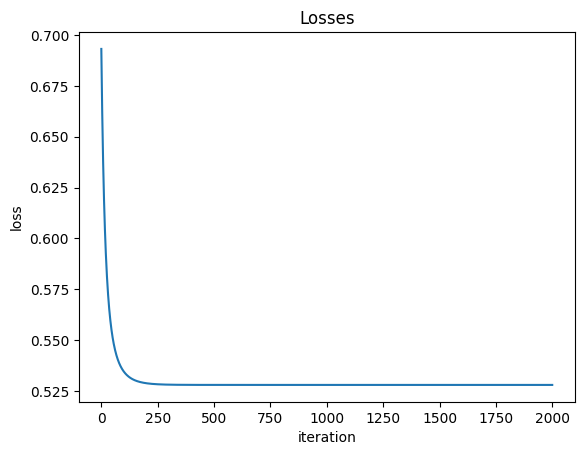

In [43]:
plt.figure()
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Losses")
plt.show()